In [253]:
import pandas as pd
import matplotlib.pyplot as plt
from database.adatabase import ADatabase
import matplotlib.dates as mdates
from datetime import datetime, timedelta
market = ADatabase("market")

In [254]:
market = ADatabase("market")
market.connect()
df = market.retrieve("crypto").sort_values("date")
market.disconnect()
df["date"] = pd.to_datetime(df["date"])
# Calculate the rolling mean and standard deviation
window = 30  # You can adjust this value based on your strategy
offset = 1
df['rolling_mean'] = df['adjclose'].rolling(window=window).mean()
df["signal"] = df["rolling_mean"] > df["adjclose"]
df["buy_price"] = df["adjclose"].shift(1)
df["sell_price"] = df["adjclose"].shift(2)
df["return"] = (df["sell_price"] - df["buy_price"]) / df["buy_price"]
df.dropna(inplace=True)

In [259]:
trades = df[df["signal"]==True].iloc[::offset]
trades["cr"] = (trades["return"] + 1).cumprod()
trades["br"] = trades["adjclose"].pct_change().cumsum()+1

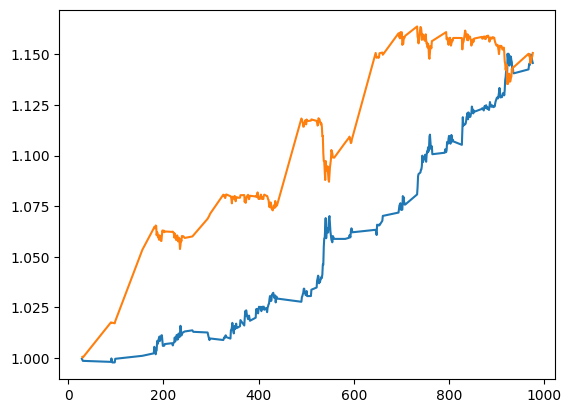

In [260]:
plt.plot(trades["cr"])
plt.plot(trades["br"])
plt.show()

In [257]:
1.03 ** 520

4735401.928596537